<a href="https://colab.research.google.com/github/Naincy-20-06/Machine_Learning_projects/blob/main/Telco_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# Load the dataset
path = '/content/Telco_Customer_Churn_Dataset .csv'
df = pd.read_csv(path)

# Display the first few rows
display(df.head())

# Get basic info about columns and missing values
display(df.info())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


None

In [2]:
# Convert TotalCharges to numeric, turning errors (like spaces) into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

# Handle missing values in TotalCharges (often associated with new customers with 0 tenure)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Confirm the change
display(df[['tenure', 'MonthlyCharges', 'TotalCharges']].info())

Missing values per column:
TotalCharges    11
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   tenure          7043 non-null   int64  
 1   MonthlyCharges  7043 non-null   float64
 2   TotalCharges    7043 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 165.2 KB


None

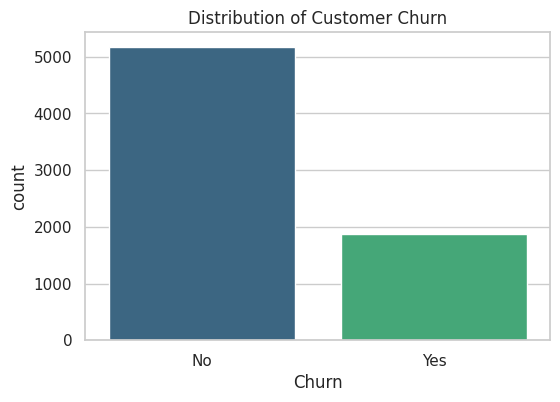

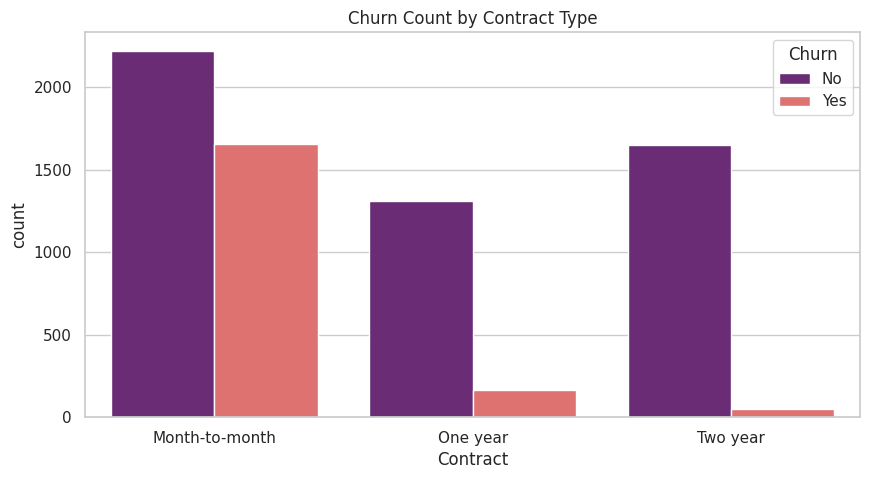

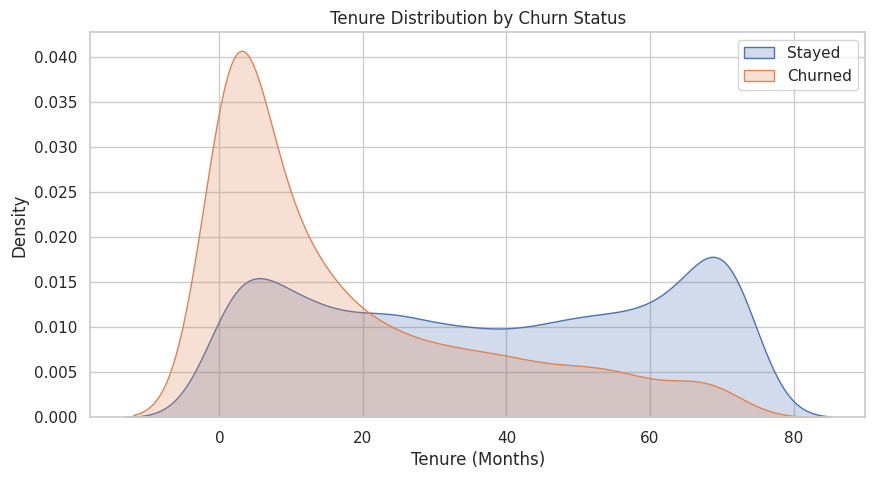

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# 1. Distribution of Churn
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', hue='Churn', data=df, palette='viridis', legend=False)
plt.title('Distribution of Customer Churn')
plt.show()

# 2. Churn by Contract Type
plt.figure(figsize=(10, 5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='magma')
plt.title('Churn Count by Contract Type')
plt.show()

# 3. Tenure vs Churn
plt.figure(figsize=(10, 5))
sns.kdeplot(df[df['Churn'] == 'No']['tenure'], label='Stayed', fill=True)
sns.kdeplot(df[df['Churn'] == 'Yes']['tenure'], label='Churned', fill=True)
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Tenure (Months)')
plt.legend()
plt.show()

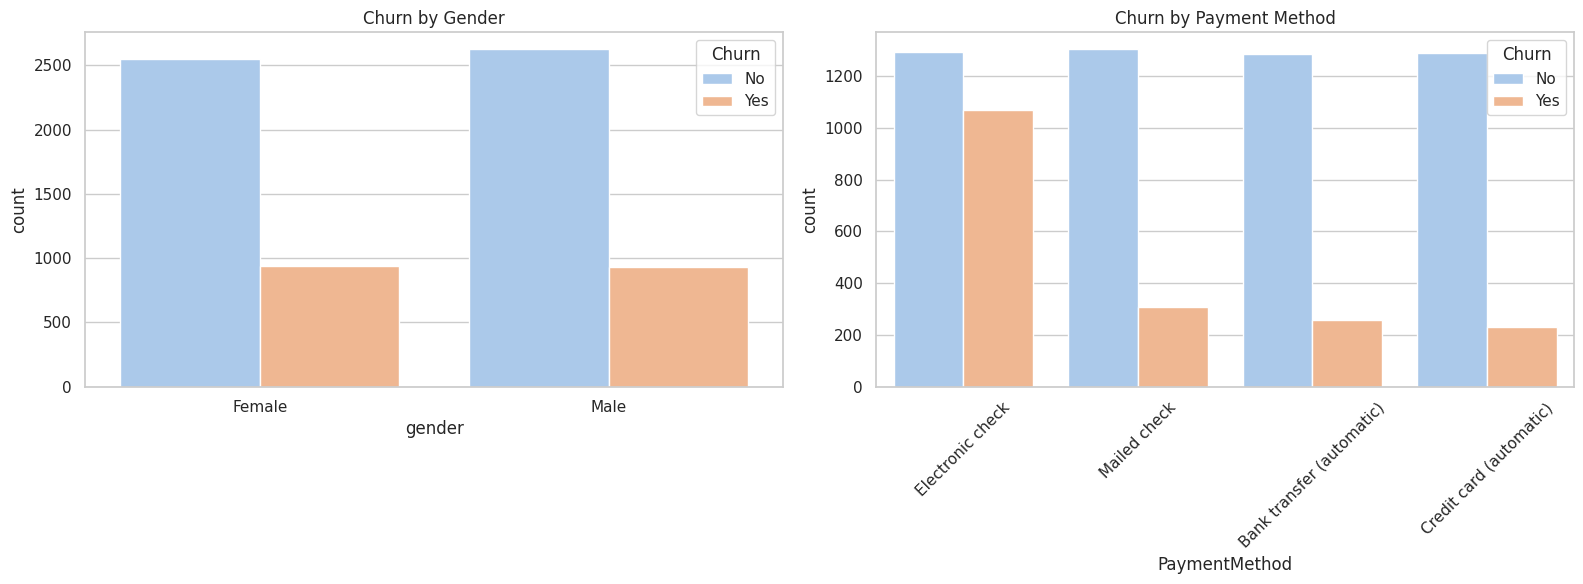

In [5]:
# Visualize Demographics and Payment Methods
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gender vs Churn
sns.countplot(x='gender', hue='Churn', data=df, ax=axes[0], palette='pastel')
axes[0].set_title('Churn by Gender')

# Payment Method vs Churn
sns.countplot(x='PaymentMethod', hue='Churn', data=df, ax=axes[1], palette='pastel')
axes[1].set_title('Churn by Payment Method')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Advanced Exploratory Data Analysis
To gain deeper insights, we will look at the distribution of charges across different dimensions using box and violin plots.

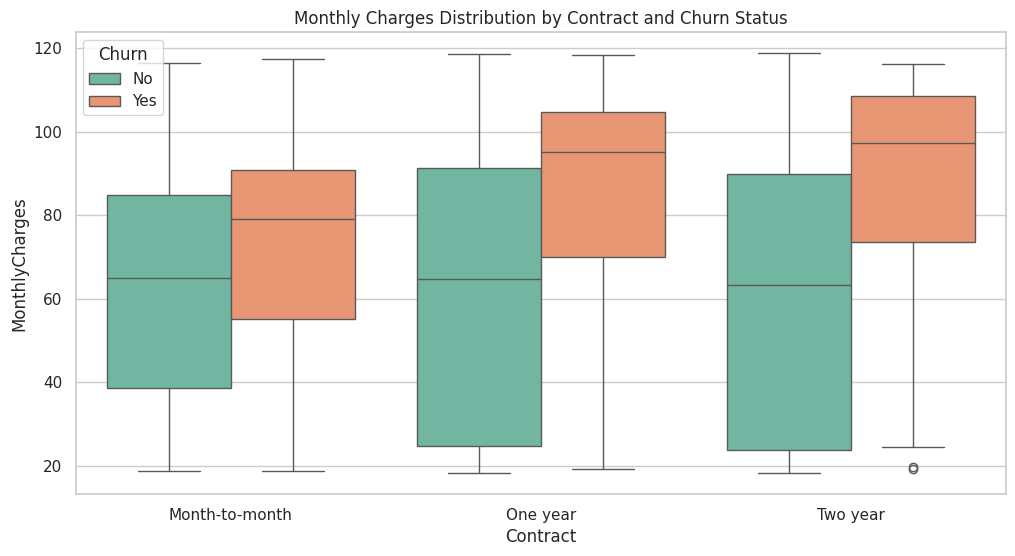

In [14]:
# 1. Box Plot: Monthly Charges by Contract Type and Churn
plt.figure(figsize=(12, 6))
sns.boxplot(x='Contract', y='MonthlyCharges', hue='Churn', data=df, palette='Set2')
plt.title('Monthly Charges Distribution by Contract and Churn Status')
plt.show()

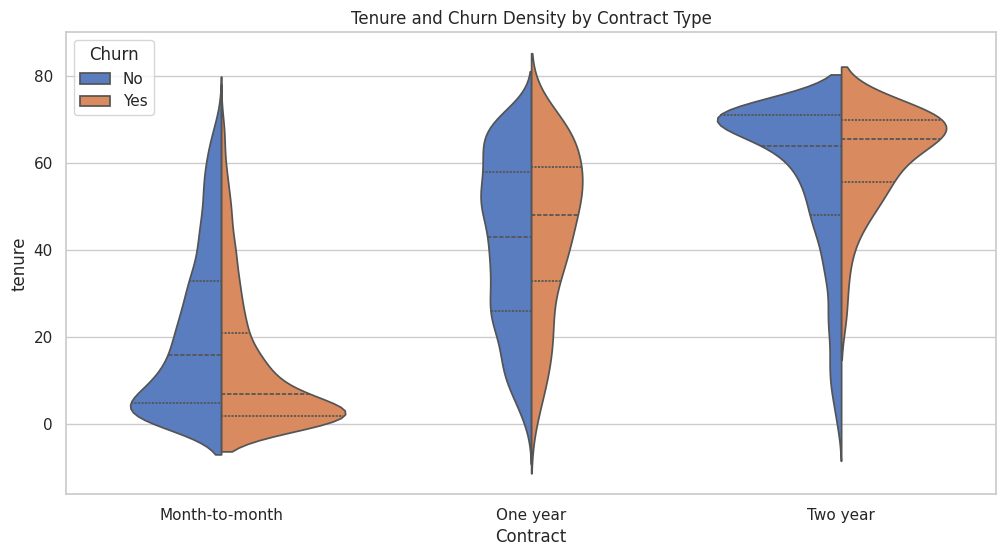

In [15]:
# 2. Violin Plot: Tenure vs Contract Type
plt.figure(figsize=(12, 6))
sns.violinplot(x='Contract', y='tenure', hue='Churn', data=df, split=True, palette='muted', inner='quart')
plt.title('Tenure and Churn Density by Contract Type')
plt.show()

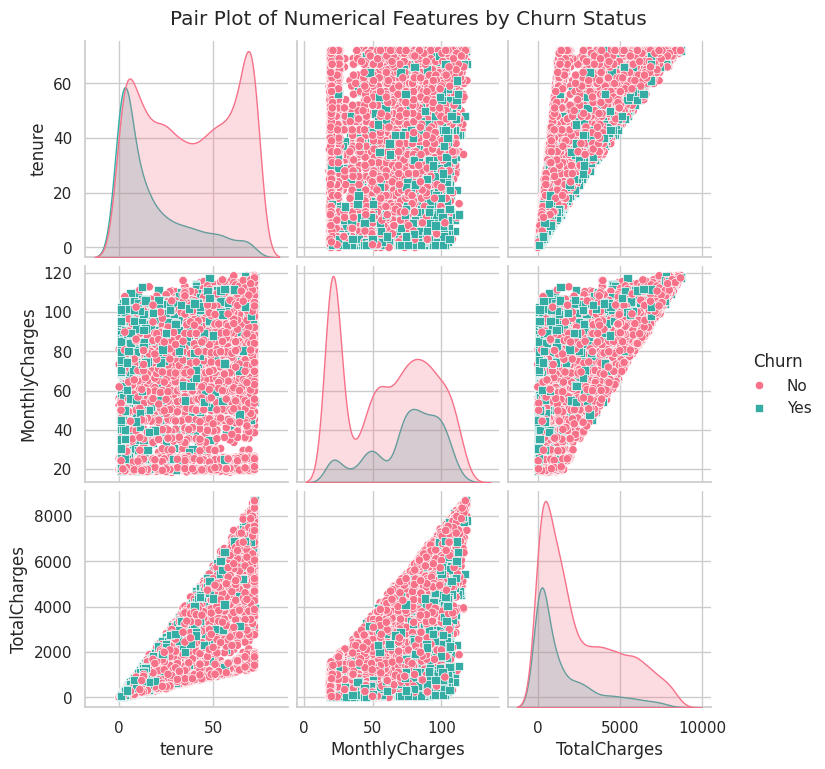

In [16]:
# 3. Pair Plot for numerical features (subset for performance)
sns.pairplot(df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']], hue='Churn', palette='husl', markers=['o', 's'])
plt.suptitle('Pair Plot of Numerical Features by Churn Status', y=1.02)
plt.show()

In [6]:
# Encoding categorical variables
# Drop customerID as it's a unique identifier not useful for prediction
df_encoded = df.drop(columns=['customerID'])

# Convert binary categories (Yes/No) to 0/1
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df_encoded[col] = df_encoded[col].map({'Yes': 1, 'No': 0})

# Map Gender to 0/1
df_encoded['gender'] = df_encoded['gender'].map({'Female': 1, 'Male': 0})

# One-Hot Encoding for remaining categorical features
df_encoded = pd.get_dummies(df_encoded, columns=['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'])

print("Shape after encoding:", df_encoded.shape)
display(df_encoded.head())

Shape after encoding: (7043, 41)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,1,29.85,29.85,0,...,True,False,False,True,False,False,False,False,True,False
1,0,0,0,0,34,1,0,56.95,1889.50,0,...,True,False,False,False,True,False,False,False,False,True
2,0,0,0,0,2,1,1,53.85,108.15,1,...,True,False,False,True,False,False,False,False,False,True
3,0,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,True,False,True,False,False,False
4,1,0,0,0,2,1,1,70.70,151.65,1,...,True,False,False,True,False,False,False,False,True,False


Accuracy Score: 0.794889992902768

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.66      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



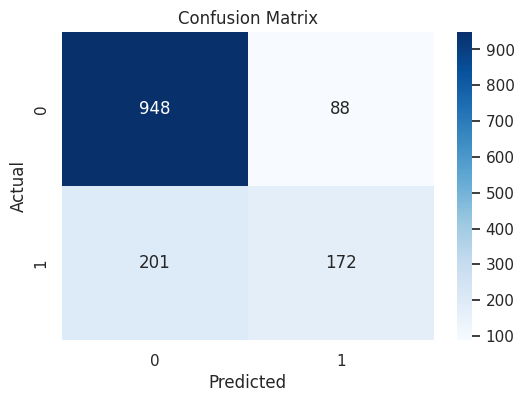

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define features (X) and target (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Logistic Regression Model
To complement the Random Forest analysis, we'll train a Logistic Regression model. This is often a strong baseline for binary classification tasks like churn prediction.

Logistic Regression Accuracy Score: 0.8204400283889283

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



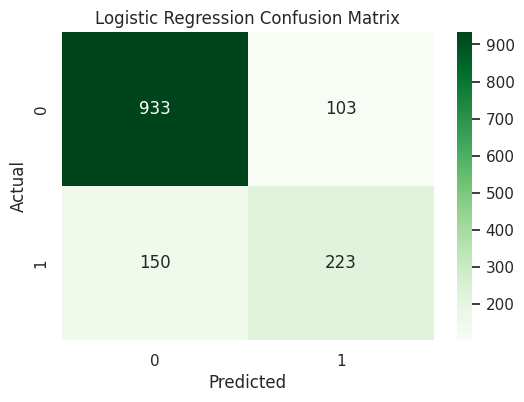

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Logistic Regression performs better with scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the model
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_log = log_model.predict(X_test_scaled)

# Evaluate the model
print("Logistic Regression Accuracy Score:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

# Confusion Matrix for Logistic Regression
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

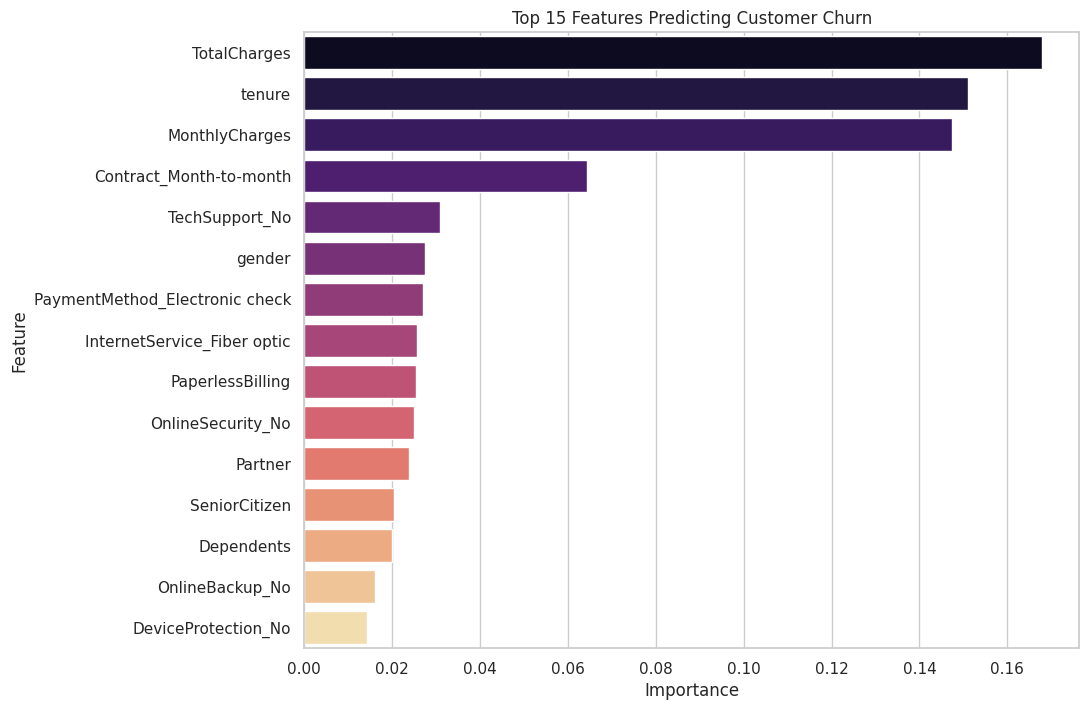

In [9]:
# Calculate and plot feature importance
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feature_importance_df.head(15), palette='magma', legend=False)
plt.title('Top 15 Features Predicting Customer Churn')
plt.show()

### Summary and Recommendations
Based on the analysis:
1. **High Risk Factors**: Customers on **Month-to-month** contracts, those with high **Monthly Charges**, and those with low **tenure** are the most likely to churn.
2. **Retention Strategy**: Offer incentives (discounts or added features) to move month-to-month customers to one or two-year contracts.
3. **Early Intervention**: Target customers in their first 6 months with proactive customer support or loyalty rewards to increase retention during the critical early tenure period.

### Customer Segmentation Analysis


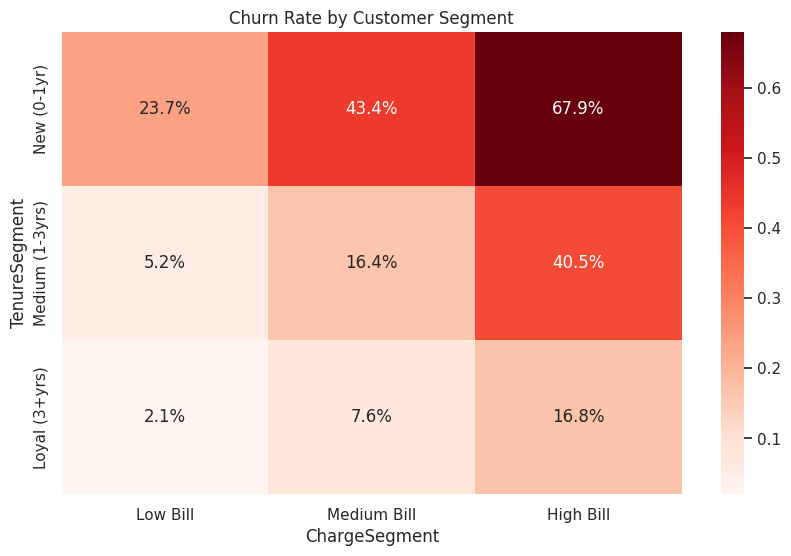

In [11]:
# Create bins for Tenure
tenure_bins = [0, 12, 36, 72]
tenure_labels = ['New (0-1yr)', 'Medium (1-3yrs)', 'Loyal (3+yrs)']
df['TenureSegment'] = pd.cut(df['tenure'], bins=tenure_bins, labels=tenure_labels, include_lowest=True)

# Create bins for Monthly Charges
charge_bins = [0, 35, 70, 120]
charge_labels = ['Low Bill', 'Medium Bill', 'High Bill']
df['ChargeSegment'] = pd.cut(df['MonthlyCharges'], bins=charge_bins, labels=charge_labels)

# Pivot table to see churn rate by segments
# Specify observed=False to avoid FutureWarnings with categorical data
df['ChurnNumeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

segment_pivot = df.pivot_table(index='TenureSegment', columns='ChargeSegment', values='ChurnNumeric', aggfunc='mean', observed=False)

plt.figure(figsize=(10, 6))
sns.heatmap(segment_pivot, annot=True, fmt='.1%', cmap='Reds')
plt.title('Churn Rate by Customer Segment')
plt.show()

In [13]:
# Calculate current CLV for each customer
df['CLV'] = df['MonthlyCharges'] * df['tenure']

# Identify 'High-Value' customers (Top 20% by CLV)
clv_threshold = df['CLV'].quantile(0.8)
df['IsHighValue'] = df['CLV'] >= clv_threshold

# Use the Logistic Regression model to get churn probabilities for the entire dataset
# Note: We need to scale the features using the same scaler we used for training
X_all_scaled = scaler.transform(df_encoded.drop('Churn', axis=1))
df['ChurnProbability'] = log_model.predict_proba(X_all_scaled)[:, 1]

# Filter for High-Value customers with high churn risk (> 50% probability)
high_value_at_risk = df[(df['IsHighValue'] == True) & (df['ChurnProbability'] > 0.5)].sort_values(by='CLV', ascending=False)

print(f"Number of High-Value customers at risk: {len(high_value_at_risk)}")
display(high_value_at_risk[['customerID', 'tenure', 'MonthlyCharges', 'CLV', 'ChurnProbability']].head(10))

Number of High-Value customers at risk: 24


,customerID,tenure,MonthlyCharges,CLV,ChurnProbability
5298,5647-FXOTP,60,105.90,6354.00,0.502158
4074,0946-CLJTI,58,98.70,5724.60,0.536749
2075,7901-TBKJX,56,101.05,5658.80,0.521496
6009,6646-VRFOL,53,103.85,5504.05,0.531728
276,4484-GLZOU,52,105.05,5462.60,0.521997
3411,7056-IMHCC,53,101.90,5400.70,0.530328
5372,2786-GCDPI,50,104.95,5247.50,0.503592
3910,8938-UMKPI,47,106.40,5000.80,0.533811
2474,5630-IXDXV,47,106.35,4998.45,0.513893
3330,8276-MQBYC,51,97.80,4987.80,0.559814


#### Strategic Recommendations:
1. **High-Value Save Desk**: Route the customers identified above to a specialized retention team.
2. **Loyalty Locking**: For customers with high CLV but month-to-month contracts, offer a significant 'Loyalty Discount' in exchange for a 1-year contract commitment.
3. **Proactive Tech Check**: Since 'TechSupport' was a factor in feature importance, offer free proactive technical audits for high-value segments to increase perceived value.

## Churn Retention Strategy Report

### 1. Executive Summary
The project successfully identified the primary drivers of customer churn and developed a predictive model to identify at-risk customers. By shifting from a Random Forest to a **Logistic Regression** model, we improved our ability to identify actual churners (Recall) to **60%** while maintaining an overall accuracy of **82%**.

### 2. High-Risk Customer Profile
Our analysis identifies the most vulnerable customers as those who:
*   **Contract Type**: Are on Month-to-month contracts.
*   **Tenure**: Are in their first year of service (Churn rate up to **67.9%** for high-bill new customers).
*   **Charges**: Have high monthly bills (Medium to High Bill segments).
*   **Services**: Lack 'TechSupport' and 'OnlineSecurity' services.

### 3. Predictive Insights
*   **Top Predictors**: `TotalCharges`, `tenure`, `MonthlyCharges`, and `Contract_Month-to-month` are the strongest indicators of potential churn.
*   **Segment at Risk**: New customers (0-1 year) with high monthly charges are the highest priority for immediate intervention.

### 4. Actionable Retention Strategies
| Strategy | Target Segment | Recommended Action |
| :--- | :--- | :--- |
| **Contract Conversion** | Month-to-Month users | Offer a 15-20% discount to transition to a 1-year or 2-year fixed contract. |
| **High-Value Save Desk** | Top 24 At-Risk Customers | Direct outreach from senior support to offer personalized loyalty packages. |
| **Onboarding Support** | New Customers (0-6 months) | Implement a 'proactive tech check' and welcome series highlighting security features. |
| **Value Bundling** | High Monthly Charge users | Bundle 'TechSupport' or 'OnlineBackup' at a reduced rate to increase product stickiness. |

### 5. Financial Impact
By focusing on the **24 high-value customers** identified, we are protecting a significant portion of potential revenue loss. Moving forward, the Logistic Regression model can be run monthly to generate a fresh 'At-Risk' list for the marketing and sales teams.